In [1]:
pip install plotly


Defaulting to user installation because normal site-packages is not writeable
Note: you may need to restart the kernel to use updated packages.


In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px

import warnings
warnings.filterwarnings('ignore')

In [3]:
df = pd.read_csv("C:/Users/Jagdish singh/projects/datasets/chronic disease dataset.csv")


In [4]:
df.head()
df.shape
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 400 entries, 0 to 399
Data columns (total 26 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   id              400 non-null    int64  
 1   age             391 non-null    float64
 2   bp              388 non-null    float64
 3   sg              353 non-null    float64
 4   al              354 non-null    float64
 5   su              351 non-null    float64
 6   rbc             248 non-null    object 
 7   pc              335 non-null    object 
 8   pcc             396 non-null    object 
 9   ba              396 non-null    object 
 10  bgr             356 non-null    float64
 11  bu              381 non-null    float64
 12  sc              383 non-null    float64
 13  sod             313 non-null    float64
 14  pot             312 non-null    float64
 15  hemo            348 non-null    float64
 16  pcv             330 non-null    object 
 17  wc              295 non-null    obj

In [5]:
df.drop('id', axis = 1, inplace = True)

In [6]:
df.columns = ['age', 'blood_pressure', 'specific_gravity', 'albumin', 'sugar', 'red_blood_cells', 'pus_cell',
              'pus_cell_clumps', 'bacteria', 'blood_glucose_random', 'blood_urea', 'serum_creatinine', 'sodium',
              'potassium', 'haemoglobin', 'packed_cell_volume', 'white_blood_cell_count', 'red_blood_cell_count',
              'hypertension', 'diabetes_mellitus', 'coronary_artery_disease', 'appetite', 'peda_edema',
              'aanemia', 'class']

In [7]:
df.describe()

,age,blood_pressure,specific_gravity,albumin,sugar,blood_glucose_random,blood_urea,serum_creatinine,sodium,potassium,haemoglobin
count,391.000000,388.000000,353.000000,354.000000,351.000000,356.000000,381.000000,383.000000,313.000000,312.000000,348.000000
mean,51.483376,76.469072,1.017408,1.016949,0.450142,148.036517,57.425722,3.072454,137.528754,4.627244,12.526437
std,17.169714,13.683637,0.005717,1.352679,1.099191,79.281714,50.503006,5.741126,10.408752,3.193904,2.912587
min,2.000000,50.000000,1.005000,0.000000,0.000000,22.000000,1.500000,0.400000,4.500000,2.500000,3.100000
25%,42.000000,70.000000,1.010000,0.000000,0.000000,99.000000,27.000000,0.900000,135.000000,3.800000,10.300000
50%,55.000000,80.000000,1.020000,0.000000,0.000000,121.000000,42.000000,1.300000,138.000000,4.400000,12.650000
75%,64.500000,80.000000,1.020000,2.000000,0.000000,163.000000,66.000000,2.800000,142.000000,4.900000,15.000000
max,90.000000,180.000000,1.025000,5.000000,5.000000,490.000000,391.000000,76.000000,163.000000,47.000000,17.800000


In [8]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 400 entries, 0 to 399
Data columns (total 25 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   age                      391 non-null    float64
 1   blood_pressure           388 non-null    float64
 2   specific_gravity         353 non-null    float64
 3   albumin                  354 non-null    float64
 4   sugar                    351 non-null    float64
 5   red_blood_cells          248 non-null    object 
 6   pus_cell                 335 non-null    object 
 7   pus_cell_clumps          396 non-null    object 
 8   bacteria                 396 non-null    object 
 9   blood_glucose_random     356 non-null    float64
 10  blood_urea               381 non-null    float64
 11  serum_creatinine         383 non-null    float64
 12  sodium                   313 non-null    float64
 13  potassium                312 non-null    float64
 14  haemoglobin              3

In [11]:
df.packed_cell_volume.unique()

array(['44', '38', '31', '32', '35', '39', '36', '33', '29', '28', nan,
       '16', '24', '37', '30', '34', '40', '45', '27', '48', '\t?', '52',
       '14', '22', '18', '42', '17', '46', '23', '19', '25', '41', '26',
       '15', '21', '43', '20', '\t43', '47', '9', '49', '50', '53', '51',
       '54'], dtype=object)

In [12]:
df['packed_cell_volume'].unique() 
df['packed_cell_volume'].shape


(400,)

In [ ]:
# due to strings values in the column its an object column but say still you
# want to cover to numeric values

In [13]:
df['packed_cell_volume']=pd.to_numeric(df['packed_cell_volume'],errors='coerce')
#corece means ignnore string converted to nan
df.packed_cell_volume.unique()


array([44., 38., 31., 32., 35., 39., 36., 33., 29., 28., nan, 16., 24.,
       37., 30., 34., 40., 45., 27., 48., 52., 14., 22., 18., 42., 17.,
       46., 23., 19., 25., 41., 26., 15., 21., 43., 20., 47.,  9., 49.,
       50., 53., 51., 54.])

In [14]:
df['white_blood_cell_count']=pd.to_numeric(df['white_blood_cell_count'],errors='coerce')
df['red_blood_cell_count']=pd.to_numeric(df['red_blood_cell_count'],errors='coerce')


In [15]:
x=[col for col in df.columns if df[col].dtype=='object']

In [16]:
y=[col for col in df.columns if df[col].dtype !='object']

In [17]:
for data in x:
    print(df[data].unique(),data)

[nan 'normal' 'abnormal'] red_blood_cells
['normal' 'abnormal' nan] pus_cell
['notpresent' 'present' nan] pus_cell_clumps
['notpresent' 'present' nan] bacteria
['yes' 'no' nan] hypertension
['yes' 'no' ' yes' '\tno' '\tyes' nan] diabetes_mellitus
['no' 'yes' '\tno' nan] coronary_artery_disease
['good' 'poor' nan] appetite
['no' 'yes' nan] peda_edema
['no' 'yes' nan] aanemia
['ckd' 'ckd\t' 'notckd'] class


In [ ]:
for data in y:
    print(df[data].unique(),data)

In [19]:
df['class']

0         ckd
1         ckd
2         ckd
3         ckd
4         ckd
        ...  
395    notckd
396    notckd
397    notckd
398    notckd
399    notckd
Name: class, Length: 400, dtype: object

In [20]:
df['class']=df['class'].replace('ckd\t','ckd')
df['class'].unique()

array(['ckd', 'notckd'], dtype=object)

In [21]:
df['diabetes_mellitus'].unique()

array(['yes', 'no', ' yes', '\tno', '\tyes', nan], dtype=object)

In [23]:
df['diabetes_mellitus'].replace(to_replace={' yes':'yes', '\tno':'no', '\tyes':'yes'},inplace=True)
df['diabetes_mellitus'].unique()

array(['yes', 'no', nan], dtype=object)

In [24]:
df['coronary_artery_disease'].unique()
df['coronary_artery_disease'].replace(to_replace={'\tno':'no'},inplace=True)
df['coronary_artery_disease'].unique()

array(['no', 'yes', nan], dtype=object)

In [25]:
df['class'].unique()
#df['class'].dtype

array(['ckd', 'notckd'], dtype=object)

In [26]:
x,y

(['red_blood_cells',
  'pus_cell',
  'pus_cell_clumps',
  'bacteria',
  'hypertension',
  'diabetes_mellitus',
  'coronary_artery_disease',
  'appetite',
  'peda_edema',
  'aanemia',
  'class'],
 ['age',
  'blood_pressure',
  'specific_gravity',
  'albumin',
  'sugar',
  'blood_glucose_random',
  'blood_urea',
  'serum_creatinine',
  'sodium',
  'potassium',
  'haemoglobin',
  'packed_cell_volume',
  'white_blood_cell_count',
  'red_blood_cell_count'])

In [27]:
df.age.dropna(inplace=True)

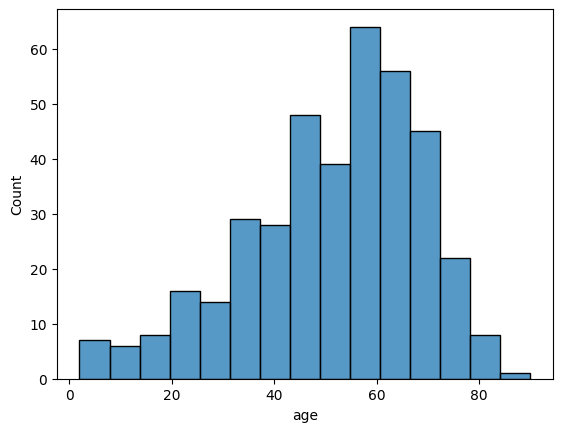

In [28]:
sns.histplot(df['age'])
plt.show()

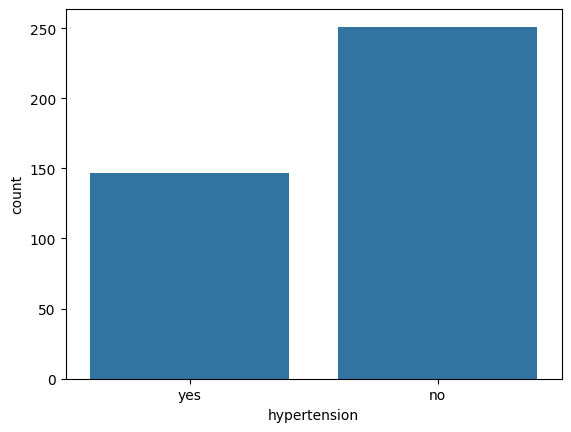

In [29]:
df['hypertension']
sns.countplot(x=df['hypertension'])
plt.show()

In [ ]:
#150 have hyper tension

In [30]:
df['blood_urea']

0      36.0
1      18.0
2      53.0
3      56.0
4      26.0
       ... 
395    49.0
396    31.0
397    26.0
398    50.0
399    18.0
Name: blood_urea, Length: 400, dtype: float64

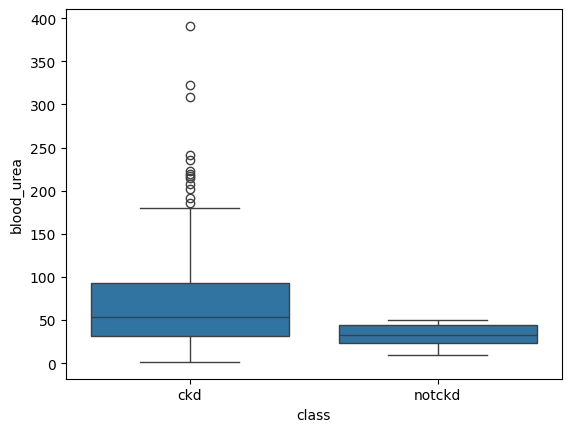

In [33]:
sns.boxplot(x=df['class'],y=df['blood_urea'], data=df)
plt.show()


In [ ]:
# people with kidney diese have higher blood urea

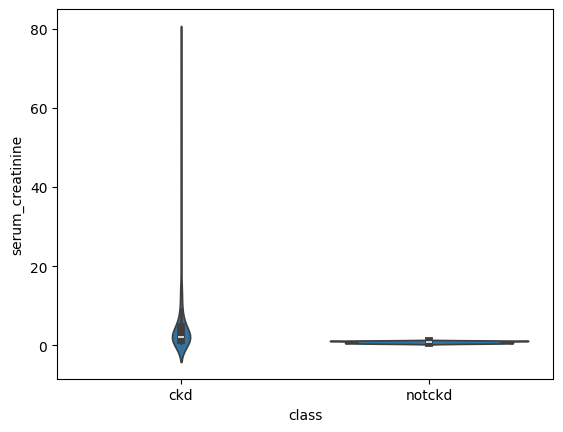

In [34]:
sns.violinplot(x='class',y=df['serum_creatinine'],data =df)
plt.show()

In [39]:
df['aanemia']

0       no
1       no
2      yes
3      yes
4       no
      ... 
395     no
396     no
397     no
398     no
399     no
Name: aanemia, Length: 400, dtype: object

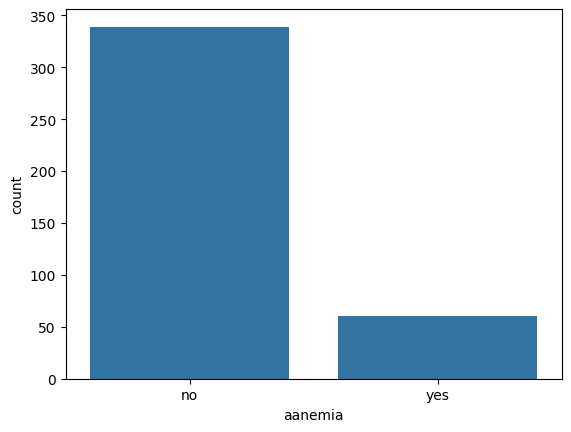

In [40]:
sns.countplot(x=df['aanemia'])
plt.show()

In [ ]:
#less people suffre from anameia

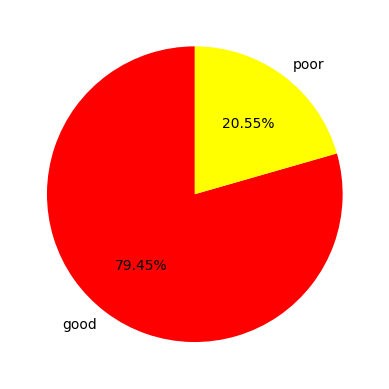

In [42]:
df.appetite
x1=df['appetite'].value_counts()
#sns.countplot(x=df['appetite'])
plt.pie(x1, data=df,labels=x1.index,autopct= '%1.2f%%', colors=["red","yellow"],startangle=90)
plt.show()

In [44]:
df.pus_cell_clumps.value_counts().reset_index()

,pus_cell_clumps,count
0,notpresent,354
1,present,42


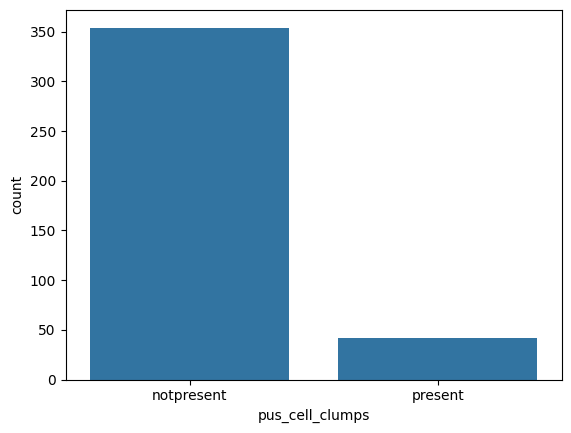

In [48]:
sns.countplot(x=df.pus_cell_clumps)
plt.show()

In [49]:
#less people have plus cell clumps
df.white_blood_cell_count.isnull().sum()
df.white_blood_cell_count.shape
len(df.white_blood_cell_count)

400

In [50]:
df.white_blood_cell_count1 = df.white_blood_cell_count.dropna()
df.white_blood_cell_count1.shape


(294,)

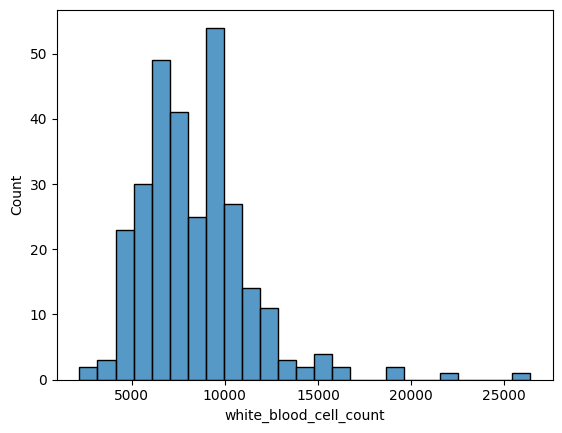

In [52]:
sns.histplot(x=df.white_blood_cell_count)
plt.show()

In [ ]:
# donut chart which has an empty hole in the center 

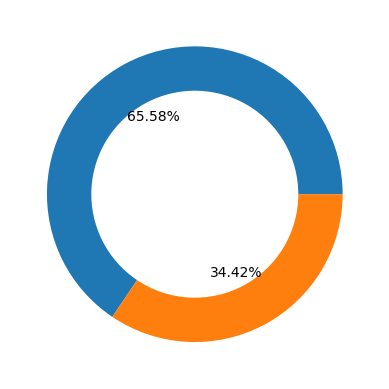

In [61]:
x3=df['diabetes_mellitus'].value_counts()
plt.pie(x3,autopct="%1.2f%%",wedgeprops=dict(width=0.3),data=x3)
plt.show()

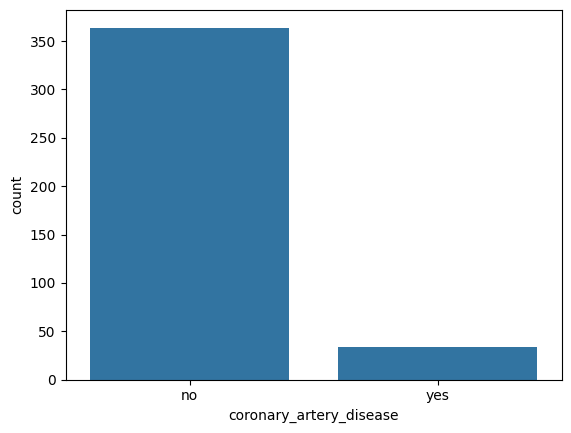

In [67]:
df.coronary_artery_disease
sns.countplot(x=df['coronary_artery_disease'],data=df)
plt.show()

In [ ]:
#less people have coronary artiery disese

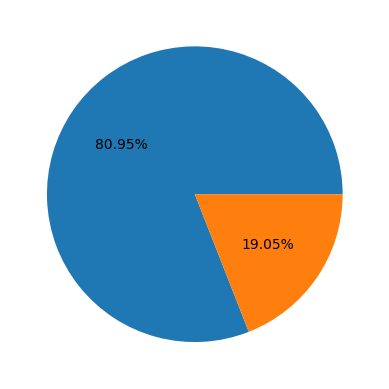

In [68]:
x4=df.peda_edema.value_counts()
plt.pie(x4,autopct="%1.2f%%")
plt.show()

In [69]:
# bivariate analysis
df['class']
df.age
df.blood_pressure

0      80.0
1      50.0
2      80.0
3      70.0
4      80.0
       ... 
395    80.0
396    70.0
397    80.0
398    60.0
399    80.0
Name: blood_pressure, Length: 400, dtype: float64

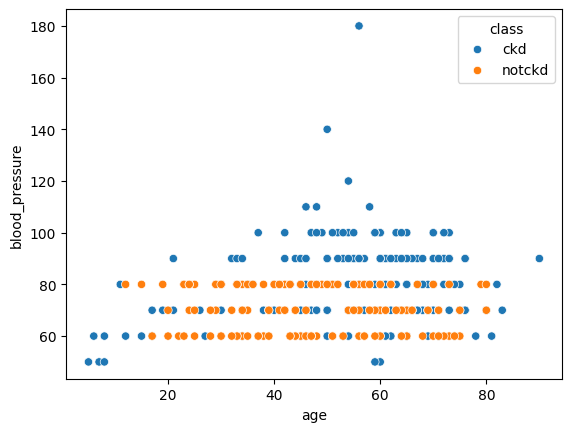

In [70]:
sns.scatterplot(x='age',y='blood_pressure', data=df,hue='class')
plt.show()

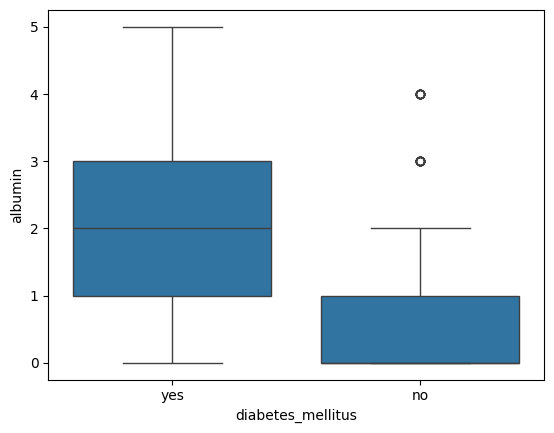

In [71]:
sns.boxplot(x='diabetes_mellitus',y ='albumin', data=df )
plt.show()

In [72]:
df['diabetes_mellitus']



0      yes
1       no
2      yes
3       no
4       no
      ... 
395     no
396     no
397     no
398     no
399     no
Name: diabetes_mellitus, Length: 400, dtype: object

In [73]:
df['hypertension']

0      yes
1       no
2       no
3      yes
4       no
      ... 
395     no
396     no
397     no
398     no
399     no
Name: hypertension, Length: 400, dtype: object

In [ ]:
#sns.barplot(x=df['diabetes_mellitus'],y=df['hypertension'], data=df,orient='v')
#plt.show()

In [74]:
pd.crosstab(df['hypertension'], df['diabetes_mellitus'])


diabetes_mellitus,no,yes
hypertension,,
no,220,31
yes,41,106


<Axes: xlabel='hypertension', ylabel='count'>

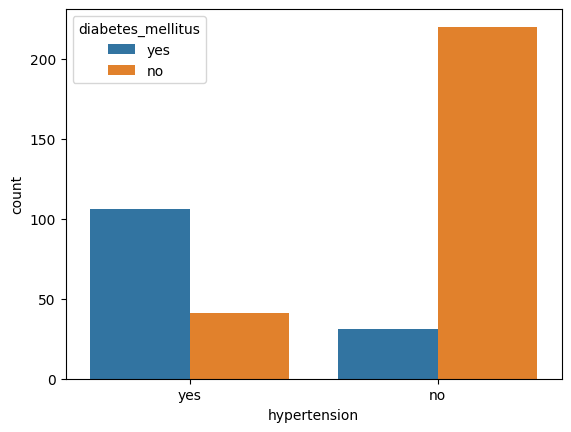

In [75]:
sns.countplot(x='hypertension', hue='diabetes_mellitus', data=df)


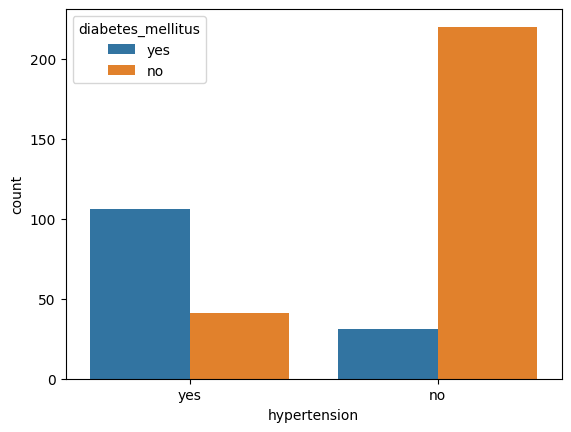

In [76]:
sns.countplot(x='hypertension', hue='diabetes_mellitus', data=df)
plt.show()


In [77]:
# mutlivaraite analysis


In [78]:
cols=['age','blood_pressure','blood_glucose_random','class']
df.columns
df[cols]

,age,blood_pressure,blood_glucose_random,class
0,48.0,80.0,121.0,ckd
1,7.0,50.0,NaN,ckd
2,62.0,80.0,423.0,ckd
3,48.0,70.0,117.0,ckd
4,51.0,80.0,106.0,ckd
...,...,...,...,...
395,55.0,80.0,140.0,notckd
396,42.0,70.0,75.0,notckd
397,12.0,80.0,100.0,notckd
398,17.0,60.0,114.0,notckd


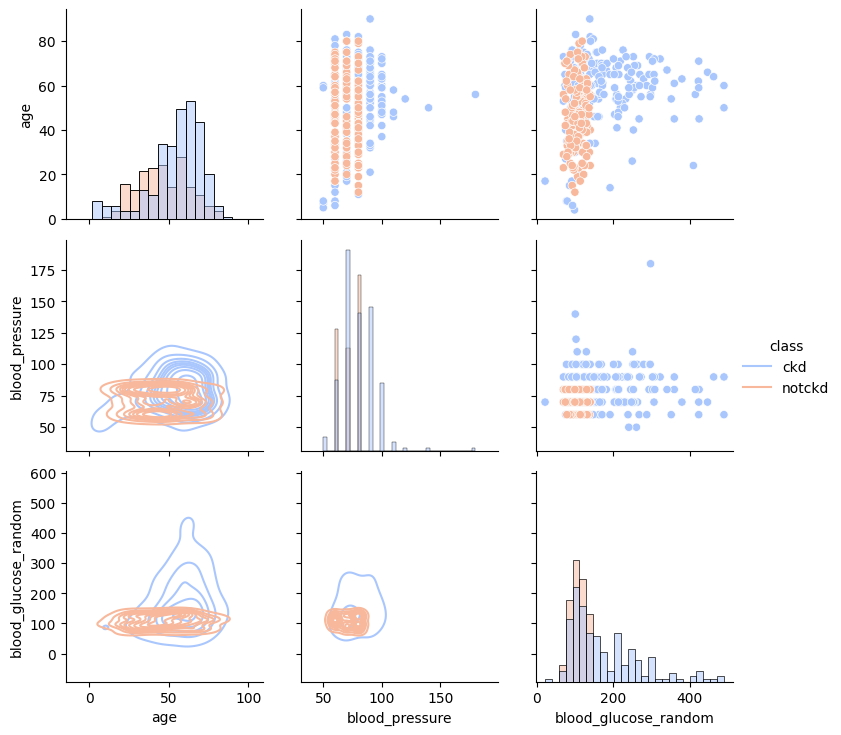

In [79]:
# important understanding
g=sns.PairGrid(df[cols],hue='class', palette='coolwarm')
g.map_upper(sns.scatterplot)
g.map_lower(sns.kdeplot,cmap='Blue_d')
g.map_diag(sns.histplot)
g.add_legend()
plt.show()

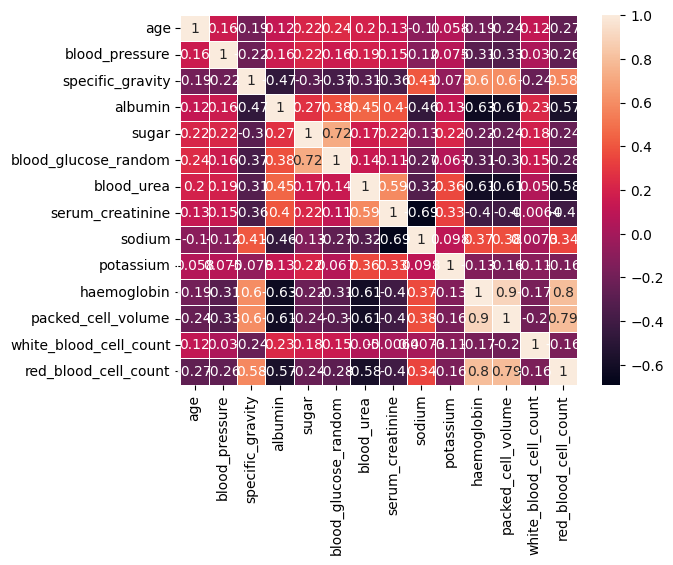

In [80]:
x5=df.corr(numeric_only=True)
sns.heatmap(x5, annot=True,linewidths=0.5)
plt.show()

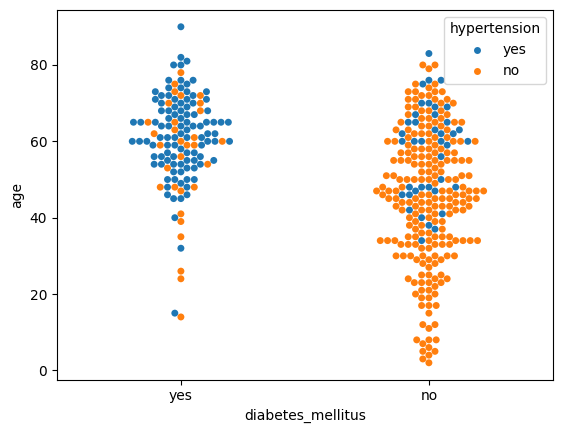

In [81]:
sns.swarmplot(x='diabetes_mellitus', y='age', hue='hypertension', data=df)
plt.show()

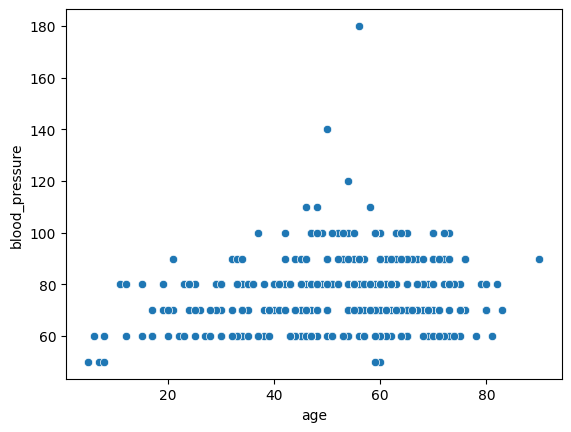

In [82]:
sns.scatterplot(data=df,x='age',y='blood_pressure')#, color='class')
plt.show()

In [83]:
fig = px.scatter(df, x = df.age, y = 'blood_pressure', color = 'class', hover_data = ['serum_creatinine', 'haemoglobin'],title = "interactive scatterplot with hover information")
fig.show()

In [ ]:
#3d plotting

In [84]:
import plotly.express as px

fig = px.scatter_3d(
    data_frame=df,
    x='age',
    y='blood_pressure',
    z='serum_creatinine',
    color='class'
)

fig.show()


In [85]:
import plotly.graph_objects as go
corr=df.corr(numeric_only=True)
fig=go.Figure(data=go.Heatmap(z=corr.values,x=corr.columns,y=corr.index))
fig.show()

In [86]:
df.isnull().sum()
df.shape #400,25
df_copy=df.copy()
df_copy.shape
df_new=df_copy.dropna()
df_new.shape




(158, 25)

In [ ]:
x

In [ ]:
y

In [87]:
mean_values=df[y].mean()
mean_values


age                         51.483376
blood_pressure              76.469072
specific_gravity             1.017408
albumin                      1.016949
sugar                        0.450142
blood_glucose_random       148.036517
blood_urea                  57.425722
serum_creatinine             3.072454
sodium                     137.528754
potassium                    4.627244
haemoglobin                 12.526437
packed_cell_volume          38.884498
white_blood_cell_count    8406.122449
red_blood_cell_count         4.707435
dtype: float64

In [ ]:
df[y]=df[y].fillna(mean_values)
df[y].isnull().sum()
df[y].isnull().value_counts()

In [ ]:
df[x].isnull().sum()

In [ ]:
mode_values=df[x].mode()
mode_values
df[x]=df[x].fillna(mode_values)
df[x].isnull().sum()


In [88]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 400 entries, 0 to 399
Data columns (total 25 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   age                      391 non-null    float64
 1   blood_pressure           388 non-null    float64
 2   specific_gravity         353 non-null    float64
 3   albumin                  354 non-null    float64
 4   sugar                    351 non-null    float64
 5   red_blood_cells          248 non-null    object 
 6   pus_cell                 335 non-null    object 
 7   pus_cell_clumps          396 non-null    object 
 8   bacteria                 396 non-null    object 
 9   blood_glucose_random     356 non-null    float64
 10  blood_urea               381 non-null    float64
 11  serum_creatinine         383 non-null    float64
 12  sodium                   313 non-null    float64
 13  potassium                312 non-null    float64
 14  haemoglobin              3

In [ ]:
remaining_cols = df.select_dtypes(include='object').columns
remaining_cols
from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()
for col in remaining_cols:
    df[col] = le.fit_transform(df[col])


In [ ]:
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder
remaining_cols = df.select_dtypes(include='object').columns
ohe=OneHotEncoder()
preprocessor = ColumnTransformer(
    transformers=[
    ('ohe','OneHotEncoderEncoder',remaining_cols)
])
df=preprocessor.fit_transform(df)